Introduction
----

In this notebook, we will implement AWQ (activation aware weight only quantization) for 4 bit weight-only quantization. By using the AWQ 4-bit weight-only quantization algorithm, combined with an efficient 4-bit kernel, we can achieve the following acceleration on the RTX 4090.

pseudo quantization
---

The following code is for pseudo quantization.Pseudo Quantization is used to simulate the effects of quantization on a model without actually quantizing the model's weights. (i.e. rounding to the nearest quantized value and then dequantizing back to a float.)

In [1]:
# core quantization method (simulated quantization)
import torch

def pseudo_quantize_tensor(w, n_bit=4, q_group_size=-1):
    org_w_shape = w.shape
    if q_group_size > 0:
        assert org_w_shape[-1] % q_group_size == 0
        w = w.reshape(-1, q_group_size)

    assert w.dim() == 2

    # Calculate the maximum (\alpha) and minimum values (\beta) in the tensor.
    max_val = w.amax(dim=1, keepdim=True)
    assert max_val.dim() == 2 and max_val.size(0) == w.size(0) and max_val.size(1) == 1
    min_val = w.amin(dim=1, keepdim=True)
    assert min_val.dim() == 2 and min_val.size(0) == w.size(0) and min_val.size(1) == 1

    # Calculate the scale factor and zero point.  (Formula 1 & 2)
    max_int = 2 ** n_bit - 1
    scales = (max_val - min_val).clamp(min=1e-5) / max_int
    assert scales.shape == max_val.shape
    zeros = (-torch.round(min_val / scales)).clamp_(0, max_int)
    assert scales.shape == min_val.shape

    assert torch.isnan(scales).sum() == 0
    assert torch.isnan(w).sum() == 0

    # Quantize W: Map values in the range [\beta, \alpha] to lie within [0, 2^b - 1] (Formula 3)
    w = torch.clamp(torch.round(w / scales) + zeros, 0, max_int)
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    # Dequantize W (pseudo quantization, the inverse transformation of Formula 3)
    w = (w - zeros) * scales
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    assert torch.isnan(w).sum() == 0

    w = w.reshape(org_w_shape)
    return w

@torch.no_grad()
def pseudo_quantize_model_weight(model, w_bit):
    for n, m in model.named_parameters():
        #if isinstance(m, nn.Linear):
        q_group_size=m.data.shape[-1]
        if 'lin.weight' in n:
            m.data = pseudo_quantize_tensor(m.data, n_bit=w_bit, q_group_size=q_group_size)
            #print(m.data)

### All libraries we need

In [32]:
import argparse
import glob
import os
import time
import copy
import statistics as stat
from tabulate import tabulate
import sys
import matplotlib.pyplot as plt
import networkx as nx


import torch
import torch.nn as nn
import torch.nn.functional as F

from sparse_softmax import Sparsemax
from torch.nn import Parameter
from torch_geometric.data import Data
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.pool.topk_pool import topk, filter_adj
from torch_geometric.utils import softmax, dense_to_sparse, add_remaining_self_loops
from torch_scatter import scatter_add
from torch_sparse import spspmm, coalesce
from torch.utils.data import random_split
from torch_geometric.data import DataLoader
from torch_geometric.datasets import TUDataset
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
from torch_geometric.nn import GCNConv

from utils import *

In [3]:
import sys
sys.argv=['']
del sys

parser = argparse.ArgumentParser()

parser.add_argument('--seed', type=int, default=777, help='random seed')
parser.add_argument('--batch_size', type=int, default=512, help='batch size')
parser.add_argument('--lr', type=float, default=0.001, help='learning rate')
parser.add_argument('--weight_decay', type=float, default=0.001, help='weight decay')
parser.add_argument('--nhid', type=int, default=128, help='hidden size')
parser.add_argument('--sample_neighbor', type=bool, default=True, help='whether sample neighbors')
parser.add_argument('--sparse_attention', type=bool, default=True, help='whether use sparse attention')
parser.add_argument('--structure_learning', type=bool, default=True, help='whether perform structure learning')
parser.add_argument('--pooling_ratio', type=float, default=0.5, help='pooling ratio')
parser.add_argument('--dropout_ratio', type=float, default=0.0, help='dropout ratio')
parser.add_argument('--lamb', type=float, default=1.0, help='trade-off parameter')
parser.add_argument('--dataset', type=str, default='PROTEINS', help='DD/PROTEINS/NCI1/NCI109/Mutagenicity/ENZYMES')
parser.add_argument('--device', type=str, default='cuda:0', help='specify cuda devices')
parser.add_argument('--epochs', type=int, default=50, help='maximum number of epochs')
parser.add_argument('--patience', type=int, default=100, help='patience for early stopping')

args = parser.parse_args()
torch.manual_seed(args.seed)

- The following code is used to calculate the model size.

In [21]:
def get_model_size(model: nn.Module, data_width=16, group_size=-1, count_nonzero_only=False):

    if group_size != -1:
        data_width += (16 + 4) / group_size

    num_elements = 0
    for param in model.parameters():
        if count_nonzero_only:
            num_elements += param.count_nonzero()
        else:
            num_elements += param.numel()
        
    return num_elements * data_width

Byte = 8
KiB = 1024 * Byte
MiB = 1024 * KiB
GiB = 1024 * MiB

In [22]:
get_model_size(model, data_width=16, group_size=-1, count_nonzero_only=True)

tensor(1206976)

In [19]:
get_model_size(model, data_width=16, group_size=-1)

1207328

### Visualization

#### For visualization load dataset from dgl library


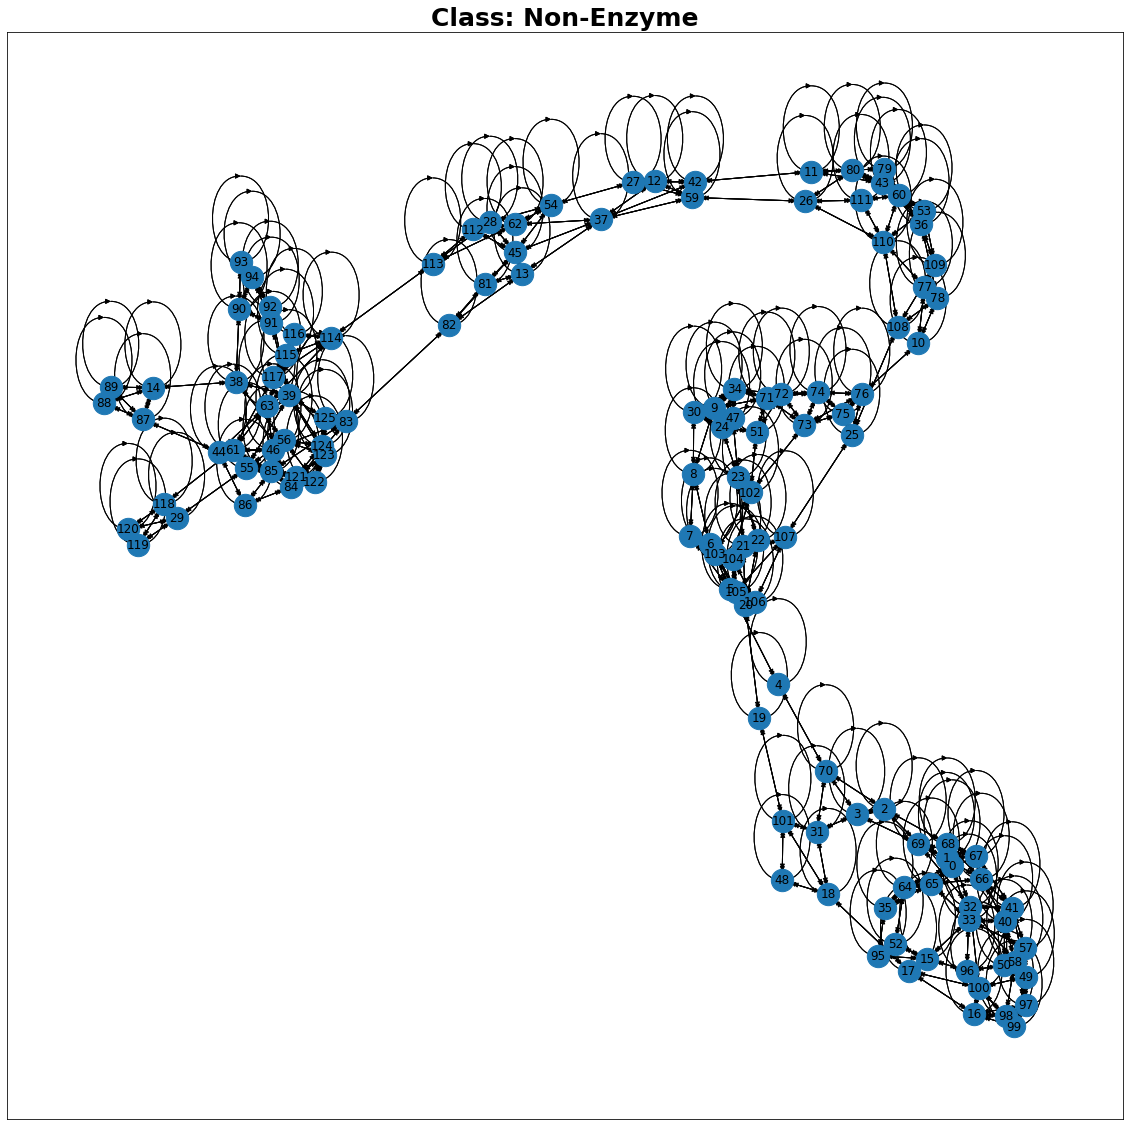

In [24]:
# Generate a synthetic dataset with 10000 graphs, ranging from 10 to 500 nodes.
import dgl
import dgl.data

dataset = dgl.data.GINDataset("PROTEINS", self_loop=True)
g, label = dataset[25]
new_label='Enzyme' if label==1 else 'Non-Enzyme'
# Create a NetworkX graph from the DGL graph
g_nx = g.to_networkx()
# Create a plot
plt.figure(figsize=(20,20))
# Draw the graph
pos = nx.spring_layout(g_nx)  # Specifying the layout of the graph
nx.draw_networkx(g_nx, pos=pos, with_labels=True, node_size=500)
# Plot the edges
nx.draw_networkx_edges(g_nx, pos=pos)
plt.title('Class: {}'.format(new_label), weight='bold',fontsize=25)

plt.savefig('fig/sample.png')
# Show the plot
plt.show()

### Load Dataset

In [5]:
dataset = TUDataset(os.path.join('data', args.dataset), name=args.dataset, use_node_attr=True)

args.num_classes = dataset.num_classes
args.num_features = dataset.num_features

print(args)

Namespace(seed=777, batch_size=512, lr=0.001, weight_decay=0.001, nhid=128, sample_neighbor=True, sparse_attention=True, structure_learning=True, pooling_ratio=0.5, dropout_ratio=0.0, lamb=1.0, dataset='PROTEINS', device='cuda:0', epochs=50, patience=100, num_classes=2, num_features=4)


In [6]:
# Print some basic information
print(f'Number of graphs: {len(dataset)}')
print(f'Number of classes: {dataset.num_classes}')
print(f'Number of node features: {dataset.num_node_features}')

Number of graphs: 1113
Number of classes: 2
Number of node features: 4


## Let's first evaluate the accuracy and model size of the FP32 Model.

### Dataloader

In [7]:
num_training = int(len(dataset) * 0.8)
num_val = int(len(dataset) * 0.1)
num_test = len(dataset) - (num_training + num_val)
training_set, validation_set, test_set = random_split(dataset, [num_training, num_val, num_test])

train_loader = DataLoader(training_set, batch_size=args.batch_size, shuffle=True)
val_loader = DataLoader(validation_set, batch_size=args.batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=args.batch_size, shuffle=False)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


### Training Process

In [8]:


class TwoHopNeighborhood(object):
    def __call__(self, data):
        edge_index, edge_attr = data.edge_index, data.edge_attr
        n = data.num_nodes

        fill = 1e16
        value = edge_index.new_full((edge_index.size(1),), fill, dtype=torch.float)

        index, value = spspmm(edge_index, value, edge_index, value, n, n, n, True)

        edge_index = torch.cat([edge_index, index], dim=1)
        if edge_attr is None:
            data.edge_index, _ = coalesce(edge_index, None, n, n)
        else:
            value = value.view(-1, *[1 for _ in range(edge_attr.dim() - 1)])
            value = value.expand(-1, *list(edge_attr.size())[1:])
            edge_attr = torch.cat([edge_attr, value], dim=0)
            #, fill_value=fill
            data.edge_index, edge_attr = coalesce(edge_index, edge_attr, n, n, op='min')
            edge_attr[edge_attr >= fill] = 0
            data.edge_attr = edge_attr

        return data

    def __repr__(self):
        return '{}()'.format(self.__class__.__name__)


class GCN(MessagePassing):
    def __init__(self, in_channels, out_channels, cached=False, bias=True, **kwargs):
        super(GCN, self).__init__(aggr='add', **kwargs)

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.cached = cached
        self.cached_result = None
        self.cached_num_edges = None

        self.weight = Parameter(torch.Tensor(in_channels, out_channels))
        nn.init.xavier_uniform_(self.weight.data)

        if bias:
            self.bias = Parameter(torch.Tensor(out_channels))
            nn.init.zeros_(self.bias.data)
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        self.cached_result = None
        self.cached_num_edges = None

    @staticmethod
    def norm(edge_index, num_nodes, edge_weight, dtype=None):
        if edge_weight is None:
            edge_weight = torch.ones((edge_index.size(1),), dtype=dtype, device=edge_index.device)

        row, col = edge_index
        deg = scatter_add(edge_weight, row, dim=0, dim_size=num_nodes)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        return edge_index, deg_inv_sqrt[row] * edge_weight * deg_inv_sqrt[col]

    def forward(self, x, edge_index, edge_weight=None):
        x = torch.matmul(x, self.weight)

        if self.cached and self.cached_result is not None:
            if edge_index.size(1) != self.cached_num_edges:
                raise RuntimeError(
                    'Cached {} number of edges, but found {}'.format(self.cached_num_edges, edge_index.size(1)))

        if not self.cached or self.cached_result is None:
            self.cached_num_edges = edge_index.size(1)
            edge_index, norm = self.norm(edge_index, x.size(0), edge_weight, x.dtype)
            self.cached_result = edge_index, norm

        edge_index, norm = self.cached_result

        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

    def update(self, aggr_out):
        if self.bias is not None:
            aggr_out = aggr_out + self.bias
        return aggr_out

    def __repr__(self):
        return '{}({}, {})'.format(self.__class__.__name__, self.in_channels, self.out_channels)


class NodeInformationScore(MessagePassing):
    def __init__(self, improved=False, cached=False, **kwargs):
        super(NodeInformationScore, self).__init__(aggr='add', **kwargs)

        self.improved = improved
        self.cached = cached
        self.cached_result = None
        self.cached_num_edges = None

    @staticmethod
    def norm(edge_index, num_nodes, edge_weight, dtype=None):
        if edge_weight is None:
            edge_weight = torch.ones((edge_index.size(1),), dtype=dtype, device=edge_index.device)

        row, col = edge_index
        deg = scatter_add(edge_weight, row, dim=0, dim_size=num_nodes)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        edge_index, edge_weight = add_remaining_self_loops(edge_index, edge_weight, 0, num_nodes)

        row, col = edge_index
        expand_deg = torch.zeros((edge_weight.size(0),), dtype=dtype, device=edge_index.device)
        expand_deg[-num_nodes:] = torch.ones((num_nodes,), dtype=dtype, device=edge_index.device)

        return edge_index, expand_deg - deg_inv_sqrt[row] * edge_weight * deg_inv_sqrt[col]

    def forward(self, x, edge_index, edge_weight):
        if self.cached and self.cached_result is not None:
            if edge_index.size(1) != self.cached_num_edges:
                raise RuntimeError(
                    'Cached {} number of edges, but found {}'.format(self.cached_num_edges, edge_index.size(1)))

        if not self.cached or self.cached_result is None:
            self.cached_num_edges = edge_index.size(1)
            edge_index, norm = self.norm(edge_index, x.size(0), edge_weight, x.dtype)
            self.cached_result = edge_index, norm

        edge_index, norm = self.cached_result

        return self.propagate(edge_index, x=x, norm=norm)

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j

    def update(self, aggr_out):
        return aggr_out


class HGPSLPool(torch.nn.Module):
    def __init__(self, in_channels, ratio=0.8, sample=False, sparse=False, sl=True, lamb=1.0, negative_slop=0.2):
        super(HGPSLPool, self).__init__()
        self.in_channels = in_channels
        self.ratio = ratio
        self.sample = sample
        self.sparse = sparse
        self.sl = sl
        self.negative_slop = negative_slop
        self.lamb = lamb

        self.att = Parameter(torch.Tensor(1, self.in_channels * 2))
        nn.init.xavier_uniform_(self.att.data)
        self.sparse_attention = Sparsemax()
        self.neighbor_augment = TwoHopNeighborhood()
        self.calc_information_score = NodeInformationScore()

    def forward(self, x, edge_index, edge_attr, batch=None):
        if batch is None:
            batch = edge_index.new_zeros(x.size(0))

        x_information_score = self.calc_information_score(x, edge_index, edge_attr)
        score = torch.sum(torch.abs(x_information_score), dim=1)

        # Graph Pooling
        original_x = x
        perm = topk(score, self.ratio, batch)
        x = x[perm]
        batch = batch[perm]
        induced_edge_index, induced_edge_attr = filter_adj(edge_index, edge_attr, perm, num_nodes=score.size(0))

        # Discard structure learning layer, directly return
        if self.sl is False:
            return x, induced_edge_index, induced_edge_attr, batch

        # Structure Learning
        if self.sample:
            # A fast mode for large graphs.
            # In large graphs, learning the possible edge weights between each pair of nodes is time consuming.
            # To accelerate this process, we sample it's K-Hop neighbors for each node and then learn the
            # edge weights between them.
            k_hop = 3
            if edge_attr is None:
                edge_attr = torch.ones((edge_index.size(1),), dtype=torch.float, device=edge_index.device)

            hop_data = Data(x=original_x, edge_index=edge_index, edge_attr=edge_attr)
            for _ in range(k_hop - 1):
                hop_data = self.neighbor_augment(hop_data)
            hop_edge_index = hop_data.edge_index
            hop_edge_attr = hop_data.edge_attr
            new_edge_index, new_edge_attr = filter_adj(hop_edge_index, hop_edge_attr, perm, num_nodes=score.size(0))

            new_edge_index, new_edge_attr = add_remaining_self_loops(new_edge_index, new_edge_attr, 0, x.size(0))
            row, col = new_edge_index
            weights = (torch.cat([x[row], x[col]], dim=1) * self.att).sum(dim=-1)
            weights = F.leaky_relu(weights, self.negative_slop) + new_edge_attr * self.lamb
            adj = torch.zeros((x.size(0), x.size(0)), dtype=torch.float, device=x.device)
            adj[row, col] = weights
            new_edge_index, weights = dense_to_sparse(adj)
            row, col = new_edge_index
            if self.sparse:
                new_edge_attr = self.sparse_attention(weights, row)
            else:
                new_edge_attr = softmax(weights, row, x.size(0))
            # filter out zero weight edges
            adj[row, col] = new_edge_attr
            new_edge_index, new_edge_attr = dense_to_sparse(adj)
            # release gpu memory
            del adj
            torch.cuda.empty_cache()
        else:
            # Learning the possible edge weights between each pair of nodes in the pooled subgraph, relative slower.
            if edge_attr is None:
                induced_edge_attr = torch.ones((induced_edge_index.size(1),), dtype=x.dtype,
                                               device=induced_edge_index.device)
            num_nodes = scatter_add(batch.new_ones(x.size(0)), batch, dim=0)
            shift_cum_num_nodes = torch.cat([num_nodes.new_zeros(1), num_nodes.cumsum(dim=0)[:-1]], dim=0)
            cum_num_nodes = num_nodes.cumsum(dim=0)
            adj = torch.zeros((x.size(0), x.size(0)), dtype=torch.float, device=x.device)
            # Construct batch fully connected graph in block diagonal matirx format
            for idx_i, idx_j in zip(shift_cum_num_nodes, cum_num_nodes):
                adj[idx_i:idx_j, idx_i:idx_j] = 1.0
            new_edge_index, _ = dense_to_sparse(adj)
            row, col = new_edge_index

            weights = (torch.cat([x[row], x[col]], dim=1) * self.att).sum(dim=-1)
            weights = F.leaky_relu(weights, self.negative_slop)
            adj[row, col] = weights
            induced_row, induced_col = induced_edge_index

            adj[induced_row, induced_col] += induced_edge_attr * self.lamb
            weights = adj[row, col]
            if self.sparse:
                new_edge_attr = self.sparse_attention(weights, row)
            else:
                new_edge_attr = softmax(weights, row, x.size(0))
            # filter out zero weight edges
            adj[row, col] = new_edge_attr
            new_edge_index, new_edge_attr = dense_to_sparse(adj)
            # release gpu memory
            del adj
            torch.cuda.empty_cache()

        return x, new_edge_index, new_edge_attr, batch


In [9]:



class Model(torch.nn.Module):
    def __init__(self, args):
        super(Model, self).__init__()
        self.args = args
        self.num_features = args.num_features
        self.nhid = args.nhid
        self.num_classes = args.num_classes
        self.pooling_ratio = args.pooling_ratio
        self.dropout_ratio = args.dropout_ratio
        self.sample = args.sample_neighbor
        self.sparse = args.sparse_attention
        self.sl = args.structure_learning
        self.lamb = args.lamb

        self.conv1 = GCNConv(self.num_features, self.nhid)
        self.conv2 = GCN(self.nhid, self.nhid)
        self.conv3 = GCN(self.nhid, self.nhid)

        self.pool1 = HGPSLPool(self.nhid, self.pooling_ratio, self.sample, self.sparse, self.sl, self.lamb)
        self.pool2 = HGPSLPool(self.nhid, self.pooling_ratio, self.sample, self.sparse, self.sl, self.lamb)

        self.lin1 = torch.nn.Linear(self.nhid * 2, self.nhid)
        self.lin2 = torch.nn.Linear(self.nhid, self.nhid // 2)
        self.lin3 = torch.nn.Linear(self.nhid // 2, self.num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = None

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x, edge_index, edge_attr, batch = self.pool1(x, edge_index, edge_attr, batch)
        x1 = torch.cat([gmp(x, batch), gap(x, batch)], dim=1)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x, edge_index, edge_attr, batch = self.pool2(x, edge_index, edge_attr, batch)
        x2 = torch.cat([gmp(x, batch), gap(x, batch)], dim=1)

        x = F.relu(self.conv3(x, edge_index, edge_attr))
        x3 = torch.cat([gmp(x, batch), gap(x, batch)], dim=1)

        x = F.relu(x1) + F.relu(x2) + F.relu(x3)

        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout_ratio, training=self.training)
        x = F.relu(self.lin2(x))
        x = F.dropout(x, p=self.dropout_ratio, training=self.training)
        x = F.log_softmax(self.lin3(x), dim=-1)

        return x


In [10]:
model = Model(args)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

In [11]:
def train(model, train_loader):
    loss_train = 0.0
    correct = 0
    model.train()
    optimizer.zero_grad()
    for i, data in enumerate(train_loader):
            #data = data.to(args.device)
            out = model(data)
            loss = F.nll_loss(out, data.y)
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
            pred = out.max(dim=1)[1]
            correct += pred.eq(data.y).sum().item()
    acc_train = correct / len(train_loader.dataset)
    
    return   loss_train,acc_train      


def compute_test(loader):
    model.eval()
    correct = 0.0
    loss_test = 0.0
    for data in loader:
        #data = data.to(args.device)
        out = model(data)
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y).sum().item()
        loss_test += F.nll_loss(out, data.y).item()
    return correct / len(loader.dataset), loss_test


### Training

In [16]:
epochs=100
def run(model, train_loader):
    min_loss = 1e10
    patience_cnt = 0
    val_loss_values = []
    best_epoch = 0

    #model.train()
    t = time.time()
    for epoch in range(epochs):
        #loss_train = 0.0
        #correct = 0
        loss_train,acc_train =train(model, train_loader)
        
        acc_val, loss_val = compute_test(val_loader)
        
        if epoch % 20 == 0:
            print('Epoch: {:04d}'.format(epoch + 1), 'loss_train: {:.6f}'.format(loss_train),
                  'acc_train: {:.6f}'.format(acc_train), 'loss_val: {:.6f}'.format(loss_val),
                  'acc_val: {:.6f}'.format(acc_val), 'time: {:.6f}s'.format(time.time() - t))

        val_loss_values.append(loss_val)
        torch.save(model.state_dict(), '{}.pth'.format(epoch))
        if val_loss_values[-1] < min_loss:
            min_loss = val_loss_values[-1]
            best_epoch = epoch
            patience_cnt = 0
        else:
            patience_cnt += 1

        if patience_cnt == args.patience:
            break
 
    return best_epoch

In [15]:
# Model training
model = Model(args)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
best_model =run(model, train_loader)

C:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_sparse\matmul.py:97: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ..\aten\src\ATen\SparseCsrTensorImpl.cpp:56.)
  C = torch.sparse.mm(A, B)


Epoch: 0001 loss_train: 1.395155 acc_train: 0.480899 loss_val: 0.665049 acc_val: 0.621622 time: 15.157360s
Epoch: 0011 loss_train: 1.277580 acc_train: 0.665169 loss_val: 0.634259 acc_val: 0.729730 time: 110.677006s
Epoch: 0021 loss_train: 1.241008 acc_train: 0.695506 loss_val: 0.612200 acc_val: 0.702703 time: 208.012553s
Epoch: 0031 loss_train: 1.208271 acc_train: 0.684270 loss_val: 0.605050 acc_val: 0.711712 time: 295.193048s
Epoch: 0041 loss_train: 1.212834 acc_train: 0.688764 loss_val: 0.592675 acc_val: 0.729730 time: 384.815557s
Epoch: 0051 loss_train: 1.184912 acc_train: 0.714607 loss_val: 0.601697 acc_val: 0.711712 time: 468.897294s
Epoch: 0061 loss_train: 1.185266 acc_train: 0.708989 loss_val: 0.601511 acc_val: 0.738739 time: 544.550513s
Epoch: 0071 loss_train: 1.180131 acc_train: 0.716854 loss_val: 0.583601 acc_val: 0.756757 time: 621.170424s
Epoch: 0081 loss_train: 1.158400 acc_train: 0.719101 loss_val: 0.598906 acc_val: 0.729730 time: 696.639880s
Epoch: 0091 loss_train: 1.143

In [16]:
test_acc, test_loss = compute_test(test_loader)
print('Test set results, loss = {:.6f}, accuracy = {:.6f}'.format(test_loss, test_acc))


Test set results, loss = 0.478716, accuracy = 0.776786


In [45]:
print(best_model)

94


In [17]:
# Restore best model for test set
#model.load_state_dict(torch.load('{}.pth'.format(best_model)))
test_acc, test_loss = compute_test(test_loader)
print('Test set results, loss = {:.6f}, accuracy = {:.6f}'.format(test_loss, test_acc))

Test set results, loss = 0.478716, accuracy = 0.776786


In [47]:
dense_model_size = get_model_size(model)

print(f"dense model has size={dense_model_size/MiB:.2f} MiB")

dense model has size=0.14 MiB


pseudo quantization
---

The following code is for pseudo quantization.Pseudo Quantization is used to simulate the effects of quantization on a model without actually quantizing the model's weights. (i.e. rounding to the nearest quantized value and then dequantizing back to a float.)


In [12]:
# core quantization method (simulated quantization)
def pseudo_quantize_tensor(w, n_bit=4, q_group_size=-1):
    org_w_shape = w.shape
    if q_group_size > 0:
        assert org_w_shape[-1] % q_group_size == 0
        w = w.reshape(-1, q_group_size)

    assert w.dim() == 2

    # Calculate the maximum (\alpha) and minimum values (\beta) in the tensor.
    max_val = w.amax(dim=1, keepdim=True)
    assert max_val.dim() == 2 and max_val.size(0) == w.size(0) and max_val.size(1) == 1
    min_val = w.amin(dim=1, keepdim=True)
    assert min_val.dim() == 2 and min_val.size(0) == w.size(0) and min_val.size(1) == 1

    # Calculate the scale factor and zero point.  (Formula 1 & 2)
    max_int = 2 ** n_bit - 1
    scales = (max_val - min_val).clamp(min=1e-5) / max_int
    assert scales.shape == max_val.shape
    zeros = (-torch.round(min_val / scales)).clamp_(0, max_int)
    assert scales.shape == min_val.shape

    assert torch.isnan(scales).sum() == 0
    assert torch.isnan(w).sum() == 0

    # Quantize W: Map values in the range [\beta, \alpha] to lie within [0, 2^b - 1] (Formula 3)
    w = torch.clamp(torch.round(w / scales) + zeros, 0, max_int)
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    # Dequantize W (pseudo quantization, the inverse transformation of Formula 3)
    w = (w - zeros) * scales
    assert w.dim() == 2 and w.size(0) == scales.size(0) and w.size(1) == q_group_size

    assert torch.isnan(w).sum() == 0

    w = w.reshape(org_w_shape)
    return w

@torch.no_grad()
def pseudo_quantize_model_weight(model, w_bit, q_group_size,):
    for n, m in model.named_parameters():
        #if isinstance(m, nn.Linear):
        if 'lin.weight' in n:
            m.data = pseudo_quantize_tensor(m.data, n_bit=w_bit, q_group_size=q_group_size)
            #print(m.data)

In [19]:
pseudo_quantize_model_weight(model, w_bit=3, q_group_size=4)


In [20]:
model_size_after_AWQ= get_model_size(model, data_width=32, group_size=1433)
print(f"model size after AWQ: {model_size_after_AWQ/MiB:.2f} MiB")

model size after AWQ: 0.29 MiB


In [21]:
# Model training
best_model_after_Quan =run(model, train_loader)

Epoch: 0001 loss_train: 1.097977 acc_train: 0.725843 loss_val: 0.616188 acc_val: 0.666667 time: 7.610913s
Epoch: 0011 loss_train: 1.131302 acc_train: 0.720225 loss_val: 0.596702 acc_val: 0.702703 time: 91.631616s
Epoch: 0021 loss_train: 1.111479 acc_train: 0.741573 loss_val: 0.610508 acc_val: 0.684685 time: 173.012238s
Epoch: 0031 loss_train: 1.081837 acc_train: 0.724719 loss_val: 0.609681 acc_val: 0.684685 time: 252.047579s
Epoch: 0041 loss_train: 1.075846 acc_train: 0.746067 loss_val: 0.592999 acc_val: 0.675676 time: 334.138165s
Epoch: 0051 loss_train: 1.072895 acc_train: 0.746067 loss_val: 0.607012 acc_val: 0.675676 time: 419.719862s
Epoch: 0061 loss_train: 1.048472 acc_train: 0.755056 loss_val: 0.605740 acc_val: 0.702703 time: 500.648129s
Epoch: 0071 loss_train: 1.065636 acc_train: 0.738202 loss_val: 0.608984 acc_val: 0.711712 time: 582.517099s
Epoch: 0081 loss_train: 1.033845 acc_train: 0.744944 loss_val: 0.607148 acc_val: 0.702703 time: 671.980239s
Epoch: 0091 loss_train: 1.02333

In [53]:
test_acc, test_loss = compute_test(test_loader)
print('Test set results, loss = {:.6f}, accuracy = {:.6f}'.format(test_loss, test_acc))

Test set results, loss = 0.584749, accuracy = 0.732143


In [22]:
model_size_after_trainig_AWQ_model= get_model_size(model, data_width=32, group_size=1433)
print(f"model size after AWQ: {model_size_after_AWQ/MiB:.2f} MiB")

model size after AWQ: 0.29 MiB


## Manual Measurement

In [17]:

Eva_final=dict()

Base_model_accuracy=[]
T_base_model=[]
Num_parm_base_model=[]
Base_model_size=[]

AWQ_model_accuracy=[]
T_AWQ_model=[]
Num_parm_AWQ_model=[]
AWQ_model_size=[]

AWQ_finetune_model_accuracy=[]
T_AWQ_finetune_model=[]
Num_parm_AWQ_finetune_model=[]
AWQ_finetune_model_size=[]

In [24]:
pseudo_quantize_model_weight(model, w_bit=3, q_group_size=4)

In [27]:
for i in range(5):
  
    files = glob.glob('*.pth')
    for f in files:
     #if f!='{}.pth'.format(best_model):
            os.remove(f)
        
    Eva=dict()
    print(f'The iteration is :{i+1} ')
    num_epoch=100
    
    print(f'Training and evaluation before Quatization ')
    # Model training
    
    model = Model(args)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    best_model =run(model, train_loader)
    print(f"The best validation accuracy is {best_model}.")
    
    # Restore best model for test set
    model.load_state_dict(torch.load('{}.pth'.format(best_model)))
    t0=time.time()
    base_model_accuracy, test_loss = compute_test(test_loader)
    t1=time.time()
    t_base_model=t1 - t0
    ###
    base_model_size = get_model_size(model,count_nonzero_only=True)
    num_parm_base_model=get_model_size(model, data_width=16, group_size=-1, count_nonzero_only=True)
    ###   
    print(f"base model has accuracy on test set={base_model_accuracy:.2f}%")
    print(f"base model has size={base_model_size/MiB:.2f} MiB")
    print(f"The time inference of base model is ={t_base_model}") 
    print(f"The number of parametrs of base model is:{num_parm_base_model}")   

    #Update my Eva dictionary
    Eva.update({'base model accuracy': base_model_accuracy,
                'time inference of base model': t_base_model,
                'number parmameters of base model': num_parm_base_model,
                'size of base model': base_model_size})


    print('_______________________________________________________')
    print(f'Quantization')
    pseudo_quantize_model_weight(model, w_bit=3, q_group_size=4)
    
    t0=time.time()
    awq_model_accuracy, test_loss = compute_test(test_loader)
    t1=time.time()
    t_awq_model=t1 - t0
    ###
    awq_model_size = get_model_size(model, data_width=16, group_size=-1, count_nonzero_only=True)
    num_parm_awq_model=get_num_parameters(model, count_nonzero_only=True)
    
    ###   
    print(f"awq model has accuracy on test set={awq_model_accuracy:.2f}%")
    print(f"awq model has size={awq_model_size/MiB:.2f} MiB")
    print(f"The time inference of awq model is ={t_awq_model}") 
    print(f"The number of parametrs of awq model is:{num_parm_awq_model}")
    print(f"awq model has size={awq_model_size/MiB:.2f} MiB, "
          f"which is {base_model_size/awq_model_size:.2f} X smaller than "
          f"the {base_model_size/MiB:.2f} MiB dense model")

    #Update my Eva dictionary
    Eva.update({'awq model accuracy': awq_model_accuracy,
                'time inference of awq model': t_awq_model,
                'number parmameters of awq model': num_parm_awq_model,
                'size of awq model': awq_model_size})
    
    print('_______________________________________________________')
    print(f'Finetuning Q Model')
    
    model = Model(args)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    best_model =run(model, train_loader)
    print(f"The best validation accuracy is {best_model}.")
    
    # Restore best model for test set
    #model.load_state_dict(torch.load('{}.pth'.format(best_model)))
  
    t0=time.time()
    awq_finetune_model_accuracy, test_loss = compute_test(test_loader)
    t1=time.time()
    t_awq_finetune_model=t1 - t0

    ###
    awq_finetune_model_size = get_model_size(model, data_width=16, group_size=-1, count_nonzero_only=True)
    num_parm_awq_finetune_model=get_num_parameters(model, count_nonzero_only=True)
      
    ###   
    print(f"awq model has accuracy on test set={awq_finetune_model_accuracy:.2f}%")
    print(f"awq model has size={awq_finetune_model_size/MiB:.2f} MiB")
    print(f"The time inference of awq model is ={t_awq_finetune_model}") 
    print(f"The number of parametrs of awq model is:{num_parm_awq_finetune_model}")
    print(f"awq model has size={awq_finetune_model_size/MiB:.2f} MiB, "
    f" which is {base_model_size/awq_finetune_model_size:.2f} X smaller than "
    f" the {base_model_size/MiB:.2f} MiB dense model")


     #Update my Eva dictionary
    Eva.update({'awq and finetune model accuracy': awq_finetune_model_accuracy,
                'time inference of awq and finetune model': t_awq_finetune_model,
                'number parmameters of awq and finetune model': num_parm_awq_finetune_model,
                'size of awq and finetune model':  awq_finetune_model_size})


  


    Base_model_accuracy.append(Eva['base model accuracy'])
    T_base_model.append(Eva['time inference of base model'])
    Num_parm_base_model.append(int(Eva['number parmameters of base model']))
    Base_model_size.append(int(Eva['size of base model']))

    AWQ_model_accuracy.append(Eva['awq model accuracy'])
    T_AWQ_model.append(Eva['time inference of awq model'])
    Num_parm_AWQ_model.append(int(Eva['number parmameters of awq model']))
    AWQ_model_size.append(int(Eva['size of awq model']))

    AWQ_finetune_model_accuracy.append(Eva['awq and finetune model accuracy'])
    T_AWQ_finetune_model.append(Eva['time inference of awq and finetune model'])
    Num_parm_AWQ_finetune_model.append(int(Eva['number parmameters of awq and finetune model']))
    AWQ_finetune_model_size.append(int(Eva['size of awq and finetune model']))


 

The iteration is :1 
Training and evaluation before Quatization 
Epoch: 0001 loss_train: 1.385667 acc_train: 0.482022 loss_val: 0.691540 acc_val: 0.621622 time: 8.658778s
Epoch: 0021 loss_train: 1.222970 acc_train: 0.680899 loss_val: 0.589069 acc_val: 0.729730 time: 163.959466s
Epoch: 0041 loss_train: 1.194703 acc_train: 0.695506 loss_val: 0.581146 acc_val: 0.720721 time: 317.493635s
Epoch: 0061 loss_train: 1.154908 acc_train: 0.704494 loss_val: 0.593591 acc_val: 0.702703 time: 468.038198s
Epoch: 0081 loss_train: 1.126999 acc_train: 0.708989 loss_val: 0.572821 acc_val: 0.756757 time: 631.984804s
The best validation accuracy is 95.
base model has accuracy on test set=0.83%
base model has size=0.14 MiB
The time inference of base model is =0.6236157417297363
The number of parametrs of base model is:1207200
_______________________________________________________
Quantization
awq model has accuracy on test set=0.79%
awq model has size=0.14 MiB
The time inference of awq model is =0.643599271

Epoch: 0001 loss_train: 1.355282 acc_train: 0.568539 loss_val: 0.665585 acc_val: 0.621622 time: 7.817255s
Epoch: 0021 loss_train: 1.229135 acc_train: 0.688764 loss_val: 0.614136 acc_val: 0.729730 time: 163.809340s
Epoch: 0041 loss_train: 1.182815 acc_train: 0.687640 loss_val: 0.577954 acc_val: 0.729730 time: 340.301718s
Epoch: 0061 loss_train: 1.153581 acc_train: 0.708989 loss_val: 0.618524 acc_val: 0.711712 time: 499.813255s
Epoch: 0081 loss_train: 1.157675 acc_train: 0.704494 loss_val: 0.566089 acc_val: 0.711712 time: 657.642022s
The best validation accuracy is 88.
base model has accuracy on test set=0.82%
base model has size=0.14 MiB
The time inference of base model is =0.5416655540466309
The number of parametrs of base model is:1207072
_______________________________________________________
Quantization
awq model has accuracy on test set=0.80%
awq model has size=0.14 MiB
The time inference of awq model is =0.572648286819458
The number of parametrs of awq model is:75341
awq model ha

In [36]:
AWQ_finetune_model_size

[1205936, 1207136, 1207024, 1207024, 1207056, 1207088]

In [30]:
Eva_final=dict()
base_model_accuracy_mean = stat.mean(Base_model_accuracy)
base_model_accuracy_std =  stat.stdev(Base_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)

Eva_final.update({'base model accuracy':float(format(base_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of base model accuracy':float(format(base_model_accuracy_std, '.3f'))})
                 
t_base_model_mean =stat.mean(T_base_model)
t_base_model_std =stat.stdev(T_base_model)  
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of base model':float(format(t_base_model_mean, '.3f'))})
Eva_final.update({'Std of time inference of base model':float(format(t_base_model_std, '.3f'))})


num_parm_base_model_mean = stat.mean(Num_parm_base_model)
num_parm_base_model_std = stat.stdev(Num_parm_base_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of base model':num_parm_base_model_mean})
Eva_final.update({'Std of number parmameters of base model':num_parm_base_model_std})

base_model_size_mean = stat.mean(Base_model_size)
base_model_size_std = stat.stdev(Base_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'base_model_size':base_model_size_mean})
Eva_final.update({'Std of base_model_size':base_model_size_std})

#################################


AWQ_model_accuracy_mean =stat.mean(AWQ_model_accuracy)
AWQ_model_accuracy_std = stat.stdev(AWQ_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ model accuracy':float(format(AWQ_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of AWQ model accuracy':float(format(AWQ_model_accuracy_std, '.3f'))})
                 

t_AWQ_model_mean = stat.mean(T_AWQ_model)
t_AWQ_model_std =stat.stdev(T_AWQ_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of AWQ model':float(format(t_AWQ_model_mean, '.3f'))})
Eva_final.update({'Std of time inference of AWQ model':float(format(t_AWQ_model_std, '.3f'))})

num_parm_AWQ_model_mean = stat.mean(Num_parm_AWQ_model)
num_parm_AWQ_model_std = stat.stdev(Num_parm_AWQ_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of AWQ model':num_parm_AWQ_model_mean})
Eva_final.update({'Std of number parmameters of AWQ model':num_parm_AWQ_model_std})

AWQ_model_size_mean =stat.mean( AWQ_model_size)
AWQ_model_size_std = stat.stdev(AWQ_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ model size':AWQ_model_size_mean})
Eva_final.update({'Std of AWQ_model_size':AWQ_model_size_std })


#################################
#################################
AWQ_finetune_model_accuracy_mean =stat.mean(AWQ_finetune_model_accuracy)
AWQ_finetune_model_accuracy_std = stat.stdev(AWQ_finetune_model_accuracy)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ finetune model accuracy':float(format(AWQ_finetune_model_accuracy_mean, '.3f'))})
Eva_final.update({'Std of AWQ finetune model accuracy':float(format(AWQ_finetune_model_accuracy_std, '.3f'))})                 

t_AWQ_finetune_model_mean =stat.mean(T_AWQ_finetune_model)
t_AWQ_finetune_model_std =stat.stdev(T_AWQ_finetune_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'time inference of AWQ finetune model':float(format(t_AWQ_finetune_model_mean,'.3f'))})
Eva_final.update({'Std of time inference of AWQ finetune model':float(format(t_AWQ_finetune_model_std,'.3f'))})

num_parm_AWQ_finetune_model_mean =stat.mean(Num_parm_AWQ_finetune_model)
num_parm_AWQ_finetune_model_std = stat.stdev(Num_parm_AWQ_finetune_model)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'number parmameters of AWQ finetune model':num_parm_AWQ_finetune_model_mean})
Eva_final.update({'Std of number parmameters of AWQ finetune model':num_parm_AWQ_finetune_model_std })

AWQ_finetune_model_size_mean = stat.mean(AWQ_finetune_model_size)
AWQ_finetune_model_size_std = stat.stdev(AWQ_finetune_model_size)
#desc = "{:.3f} ± {:.3f}".format(acc_mean,acc_std)
Eva_final.update({'AWQ finetune model size':AWQ_finetune_model_size_mean})
Eva_final.update({'Std of AWQ finetune model size':AWQ_finetune_model_size_std})



print(f"All measurement about Quatization process ")   
Eva_final

All measurement about Quatization process 


{'base model accuracy': 0.818,
 'Std of base model accuracy': 0.009,
 'time inference of base model': 0.565,
 'Std of time inference of base model': 0.057,
 'number parmameters of base model': 1206973.3333333333,
 'Std of number parmameters of base model': 147.4837844193953,
 'base_model_size': 1206973.3333333333,
 'Std of base_model_size': 147.4837844193953,
 'AWQ model accuracy': 0.81,
 'Std of AWQ model accuracy': 0.013,
 'time inference of AWQ model': 0.567,
 'Std of time inference of AWQ model': 0.064,
 'number parmameters of AWQ model': 75350.5,
 'Std of number parmameters of AWQ model': 19.107590114925536,
 'AWQ model size': 1205608,
 'Std of AWQ_model_size': 305.7214418388086,
 'AWQ finetune model accuracy': 0.82,
 'Std of AWQ finetune model accuracy': 0.029,
 'time inference of AWQ finetune model': 0.514,
 'Std of time inference of AWQ finetune model': 0.018,
 'number parmameters of AWQ finetune model': 75429.83333333333,
 'Std of number parmameters of AWQ finetune model': 28.

In [ ]:
All measurement about Quatization process 


{'base model accuracy': 0.818,
 'Std of base model accuracy': 0.009,
 'time inference of base model': 0.565,
 'Std of time inference of base model': 0.057,
 'number parmameters of base model': 1206973.3333333333,
 'Std of number parmameters of base model': 147.4837844193953,
 'base_model_size': 1206973.3333333333,
 'Std of base_model_size': 147.4837844193953,
 'AWQ model accuracy': 0.81,
 'Std of AWQ model accuracy': 0.013,
 'time inference of AWQ model': 0.567,
 'Std of time inference of AWQ model': 0.064,
 'number parmameters of AWQ model': 75350.5,
 'Std of number parmameters of AWQ model': 19.107590114925536,
 'AWQ model size': 1205608,
 'Std of AWQ_model_size': 305.7214418388086,
 'AWQ finetune model accuracy': 0.82,
 'Std of AWQ finetune model accuracy': 0.029,
 'time inference of AWQ finetune model': 0.514,
 'Std of time inference of AWQ finetune model': 0.018,
 'number parmameters of AWQ finetune model': 75429.83333333333,
 'Std of number parmameters of AWQ finetune model': 28.944199188553597,
 'AWQ finetune model size': 1206877.3333333333,
 'Std of AWQ finetune model size': 463.10718701685755}

In [37]:
# Create a table
table_data = [Base_model_accuracy,T_base_model,Num_parm_base_model, Base_model_size,
              AWQ_model_accuracy, T_AWQ_model, Num_parm_AWQ_model, AWQ_model_size,
              AWQ_finetune_model_accuracy,T_AWQ_finetune_model, Num_parm_AWQ_finetune_model, AWQ_finetune_model_size]
headers=['1', '2', '3', '4','5','6']
# Print the table
#tabulate(table_data, headers, tablefmt='fancy_grid')
# New column data
first_column_data =  ['Base_model_accuracy','T_base_model','Num_parm_base_model', 'Base_model_size',
                     'AWQ_model_accuracy', 'T_AWQ_model', 'Num_parm_AWQ_model', 'AWQ_model_size',
                     'AWQ_finetune_model_accuracy','T_AWQ_finetune_model', 'Num_parm_AWQ_finetune_model','AWQ_finetune_model_size']

# Add a custom index column
table_with_index = tabulate(table_data, headers=['parameters'] + headers,
                            showindex=first_column_data, tablefmt="fancy_grid", numalign="center")
# Print the extended table
print(table_with_index)

╒═════════════════════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╤═════════════╕
│ parameters                  │      1      │      2      │      3      │      4      │      5      │      6      │
╞═════════════════════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ Base_model_accuracy         │   0.8125    │  0.830357   │  0.821429   │  0.803571   │  0.821429   │  0.821429   │
├─────────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ T_base_model                │  0.532687   │  0.623616   │  0.490727   │   0.56373   │  0.639607   │  0.541666   │
├─────────────────────────────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Num_parm_base_model         │ 1.2069e+06  │ 1.2072e+06  │ 1.20701e+06 │ 1.20682e+06 │ 1.20685e+06 │ 1.20707e+06 │
├─────────────────────────────┼─────────────┼─────────────┼─────────────

In [39]:
# Save the table to a text file with UTF-8 encoding
with open("table.txt", "w", encoding="utf-8") as outputfile:
    outputfile.write(table_with_index)

print("Table saved to 'table.txt'")

Table saved to 'table.txt'
